tensor([0.7446, 0.7367]) tensor([3.4809])


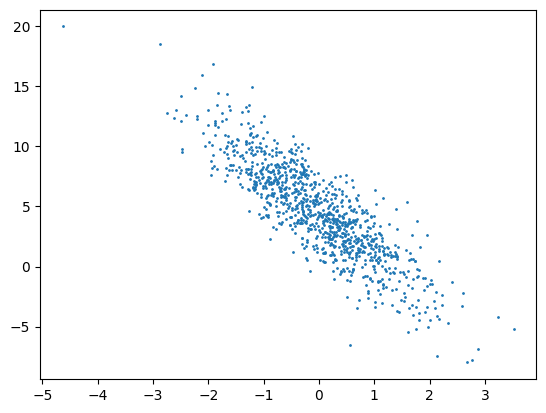

In [38]:
import torch
import random
from matplotlib import pyplot as plt

# dataset
def synthetic_data(w, b, num_examples):
    x = torch.normal(0,1,(num_examples, len(w)))
    y = torch.matmul(x,w) + b
    y += torch.normal(0,0.01,y.shape)
    
    return x, y.reshape((-1,1))

true_w = torch.tensor([2,-3.4])
true_b = 4.5

features, labels = synthetic_data(true_w, true_b, 1000)

print(features[0], labels[0])

plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)


In [39]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = indices[i:min(i+batch_size,num_examples)]
        yield features[batch_indices], labels[batch_indices]
        

In [40]:
batch_size = 10

for x, y in data_iter(batch_size, features, labels):
    print(x,'\n',y)
    break

tensor([[ 6.9530e-01, -4.5073e-01],
        [-6.7863e-01,  2.1337e+00],
        [ 8.4874e-01, -9.9741e-01],
        [-2.1962e-01, -1.5371e+00],
        [ 6.0493e-01,  5.8311e-01],
        [ 4.0184e-01, -5.6903e-04],
        [-6.0166e-01, -2.1752e-01],
        [-9.4930e-01, -1.4259e-01],
        [ 5.8736e-02,  1.5403e+00],
        [-1.3768e+00,  1.7092e+00]]) 
 tensor([[ 7.4103],
        [-4.0990],
        [ 9.5919],
        [ 9.2814],
        [ 3.7301],
        [ 5.2989],
        [ 4.0344],
        [ 3.0924],
        [-0.6153],
        [-4.0614]])


In [52]:
# 定义网络结构和参数初始化
import torch.nn as nn

class LinearNet(nn.Module):
    def __init__(self):
        super(LinearNet, self).__init__()
        # self.w = nn.Parameter(torch.normal(0,1,size=(2,1),requires_grad=True))   # 需要进行梯度更新的参数需要额外使用nn.Parameter实例化
        # self.b = nn.Parameter(torch.zeros(1,requires_grad=True))
        
        self.w = nn.Parameter(torch.zeros(size=(2,1),requires_grad=True))   # 需要进行梯度更新的参数需要额外使用nn.Parameter实例化
        self.b = nn.Parameter(torch.zeros(1,requires_grad=True))
    
    def forward(self, x):
        y = torch.matmul(x,self.w) + self.b
        return y

# 定义损失函数
def Loss(preds, labels):
    return (preds - labels.reshape(preds.shape))**2 / 2

# 定义优化函数
def sgd(batch_size, lr, paras):
    with torch.no_grad():
        for para in paras:
            para -=  lr * para.grad / batch_size
            para.grad.zero_()

# 定义循环结构
epochs = 3
lr = 0.04

model = LinearNet()
for epoch in range(epochs):
    for batch_data, batch_label in data_iter(batch_size,features,labels):
        loss = Loss(model(batch_data),batch_label)
        loss.sum().backward()
        sgd(batch_size,lr,model.parameters())
    
    with torch.no_grad():
        train_l = Loss(model(features),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        

In [53]:
# 定义循环结构
epochs = 3
lr = 0.04

model = LinearNet()
for epoch in range(epochs):
    for batch_data, batch_label in data_iter(batch_size,features,labels):
        loss = Loss(model(batch_data),batch_label)
        loss.sum().backward()
        sgd(batch_size,lr,model.parameters())
    
    with torch.no_grad():
        train_l = Loss(model(features),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        

epoch 1, loss 0.004796
epoch 2, loss 0.000052
epoch 3, loss 0.000051
